<a href="https://colab.research.google.com/github/andinaufal120/kalimantan-frp-prediction/blob/main/playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-Based FRP Estimation in Kalimantan

## Preparation

### Notebook setup

In [ ]:
# Import dependencies
from typing import Final
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
import matplotlib.pyplot as plt

# Set up Matplotlib graphical backend
%matplotlib inline

# Random state (seed) that will be used for this notebook.
SEED: Final[int] = 42

# Path of the dataset file.
PATH: Final[str] = "./data - Sheet1.csv"

### Loading data into DataFrame

In [ ]:
df = pd.read_csv(PATH)
row, col = df.shape
print(f"Loaded {row} rows, {col} cols.")

Loaded 59156 rows, 40 cols.


## Data Structure Overview

- Sample of five random rows
- Quick data info
- Numeric values summaries

In [ ]:
df.sample(n=5, random_state=SEED)

,latitude,longitude,acq_date,acq_time,satellite,frp,ndvi,evi,ndvi_age_days,ndwi,...,is_peak_burn_window,is_dry_season,solar_insolation_proxy,vpd_kpa,wind_speed_m_s,fuel_dryness,hdasi,wffsp,diurnal_burn_potential,frp_log1p
19592,-2.956348,112.847688,2023-09-25,553.0,N,3.68,0.8371,0.4122,11.0,0.166949,...,1,1,0.973379,2.604103,5.451347,1.194600,84.245592,9.768272,2.050073,1.543298
25591,-1.693370,112.561315,2023-08-29,600.0,N,22.75,0.3169,0.2602,0.0,0.169195,...,1,1,0.965926,2.343254,2.353768,3.155570,73.800222,7.427479,1.782139,3.167583
54490,-3.181511,114.727386,2023-09-27,1757.0,N,1.00,0.6780,0.3332,13.0,0.036934,...,0,1,0.000000,0.711094,2.569146,1.474926,17.956602,5.683952,0.000000,0.693147
39664,-1.714199,111.184465,2023-08-27,637.0,N,6.79,0.2493,0.2164,14.0,0.186272,...,1,1,0.911762,1.211955,1.679538,4.011231,35.864551,6.737016,0.817498,2.052841
8550,-2.732898,115.061578,2023-08-04,528.0,N,2.03,0.6397,0.3304,7.0,0.086936,...,1,1,0.992546,2.717638,2.424397,1.563233,89.357801,5.684845,2.217294,1.108563


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59156 entries, 0 to 59155
Data columns (total 40 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   latitude                59156 non-null  float64
 1   longitude               59155 non-null  float64
 2   acq_date                59155 non-null  str    
 3   acq_time                59155 non-null  float64
 4   satellite               59155 non-null  str    
 5   frp                     59155 non-null  float64
 6   ndvi                    59155 non-null  float64
 7   evi                     59155 non-null  float64
 8   ndvi_age_days           59155 non-null  float64
 9   ndwi                    59155 non-null  float64
 10  lst_siang               59155 non-null  float64
 11  lst_malam               59155 non-null  float64
 12  land_cover_type         59155 non-null  float64
 13  peat_type_class         59155 non-null  float64
 14  ssrd                    59155 non-null  float64
 

In [ ]:
df.describe()

,latitude,longitude,acq_time,frp,ndvi,evi,ndvi_age_days,ndwi,lst_siang,lst_malam,...,is_peak_burn_window,is_dry_season,solar_insolation_proxy,vpd_kpa,wind_speed_m_s,fuel_dryness,hdasi,wffsp,diurnal_burn_potential,frp_log1p
count,59156.000000,59155.000000,59155.000000,59155.000000,59155.000000,59155.000000,59155.000000,59155.000000,59155.000000,59155.00000,...,59156.000000,59156.000000,59155.000000,59155.000000,59155.000000,59155.000000,59155.000000,59155.000000,59155.000000,59155.000000
mean,-2.146674,113.386488,898.510743,7.882060,0.657471,0.424458,7.331570,0.173115,-170.103620,-219.79087,...,0.722344,0.849922,0.696984,1.748890,1.931065,1.812682,55.972967,4.377962,1.259552,1.831940
std,0.946360,1.806744,530.675086,10.808641,0.184364,0.145243,4.771615,0.146008,408.986972,434.83599,...,0.447846,0.357151,0.432814,1.052729,1.081915,1.381828,37.714234,4.221939,1.020465,0.780461
min,-4.042670,109.840189,448.000000,0.110000,-0.049000,-0.023600,0.000000,-0.376934,-999.000000,-999.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.006036,-0.000000,0.000000,0.000000,0.104360
25%,-2.871731,111.687347,541.000000,2.640000,0.559600,0.323800,3.000000,0.075737,26.550000,19.05000,...,0.000000,1.000000,0.000000,0.817323,1.160784,1.251564,21.869342,1.960568,0.000000,1.291984
50%,-2.367950,113.978159,611.000000,5.020000,0.709300,0.445200,7.000000,0.203173,29.910000,22.31000,...,1.000000,1.000000,0.952396,1.684973,1.770069,1.409841,51.620517,3.346356,1.242264,1.795087
75%,-1.493149,114.929983,1713.000000,8.880000,0.799000,0.528100,12.000000,0.286831,33.270000,23.51000,...,1.000000,1.000000,0.984041,2.554355,2.482944,1.786991,83.220434,5.452409,2.008452,2.290513
max,0.063212,116.560942,1817.000000,359.120000,0.994000,0.864200,15.000000,0.494976,49.510000,40.09000,...,1.000000,1.000000,0.999990,4.749721,6.928867,20.000000,174.821815,131.969825,4.352211,5.886437


### Dropping null rows

All columns except `latitude` has exactly one same null row.

In [ ]:
df.dropna(inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59155 entries, 0 to 59154
Data columns (total 40 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   latitude                59155 non-null  float64
 1   longitude               59155 non-null  float64
 2   acq_date                59155 non-null  str    
 3   acq_time                59155 non-null  float64
 4   satellite               59155 non-null  str    
 5   frp                     59155 non-null  float64
 6   ndvi                    59155 non-null  float64
 7   evi                     59155 non-null  float64
 8   ndvi_age_days           59155 non-null  float64
 9   ndwi                    59155 non-null  float64
 10  lst_siang               59155 non-null  float64
 11  lst_malam               59155 non-null  float64
 12  land_cover_type         59155 non-null  float64
 13  peat_type_class         59155 non-null  float64
 14  ssrd                    59155 non-null  float64
 

### Data distribution

Histogram for each numerical attributes.

array([[<Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'acq_time'}>,
        <Axes: title={'center': 'frp'}>,
        <Axes: title={'center': 'ndvi'}>,
        <Axes: title={'center': 'evi'}>,
        <Axes: title={'center': 'ndvi_age_days'}>],
       [<Axes: title={'center': 'ndwi'}>,
        <Axes: title={'center': 'lst_siang'}>,
        <Axes: title={'center': 'lst_malam'}>,
        <Axes: title={'center': 'land_cover_type'}>,
        <Axes: title={'center': 'peat_type_class'}>,
        <Axes: title={'center': 'ssrd'}>,
        <Axes: title={'center': 't2m'}>],
       [<Axes: title={'center': 'd2m'}>, <Axes: title={'center': 'u10'}>,
        <Axes: title={'center': 'v10'}>,
        <Axes: title={'center': 'tp_hourly'}>,
        <Axes: title={'center': 'mjo_phase'}>,
        <Axes: title={'center': 'oni_index'}>,
        <Axes: title={'center': 'dmi_index'}>],
       [<Axes: title={'center': 'hour_wib_decimal'}>,
 

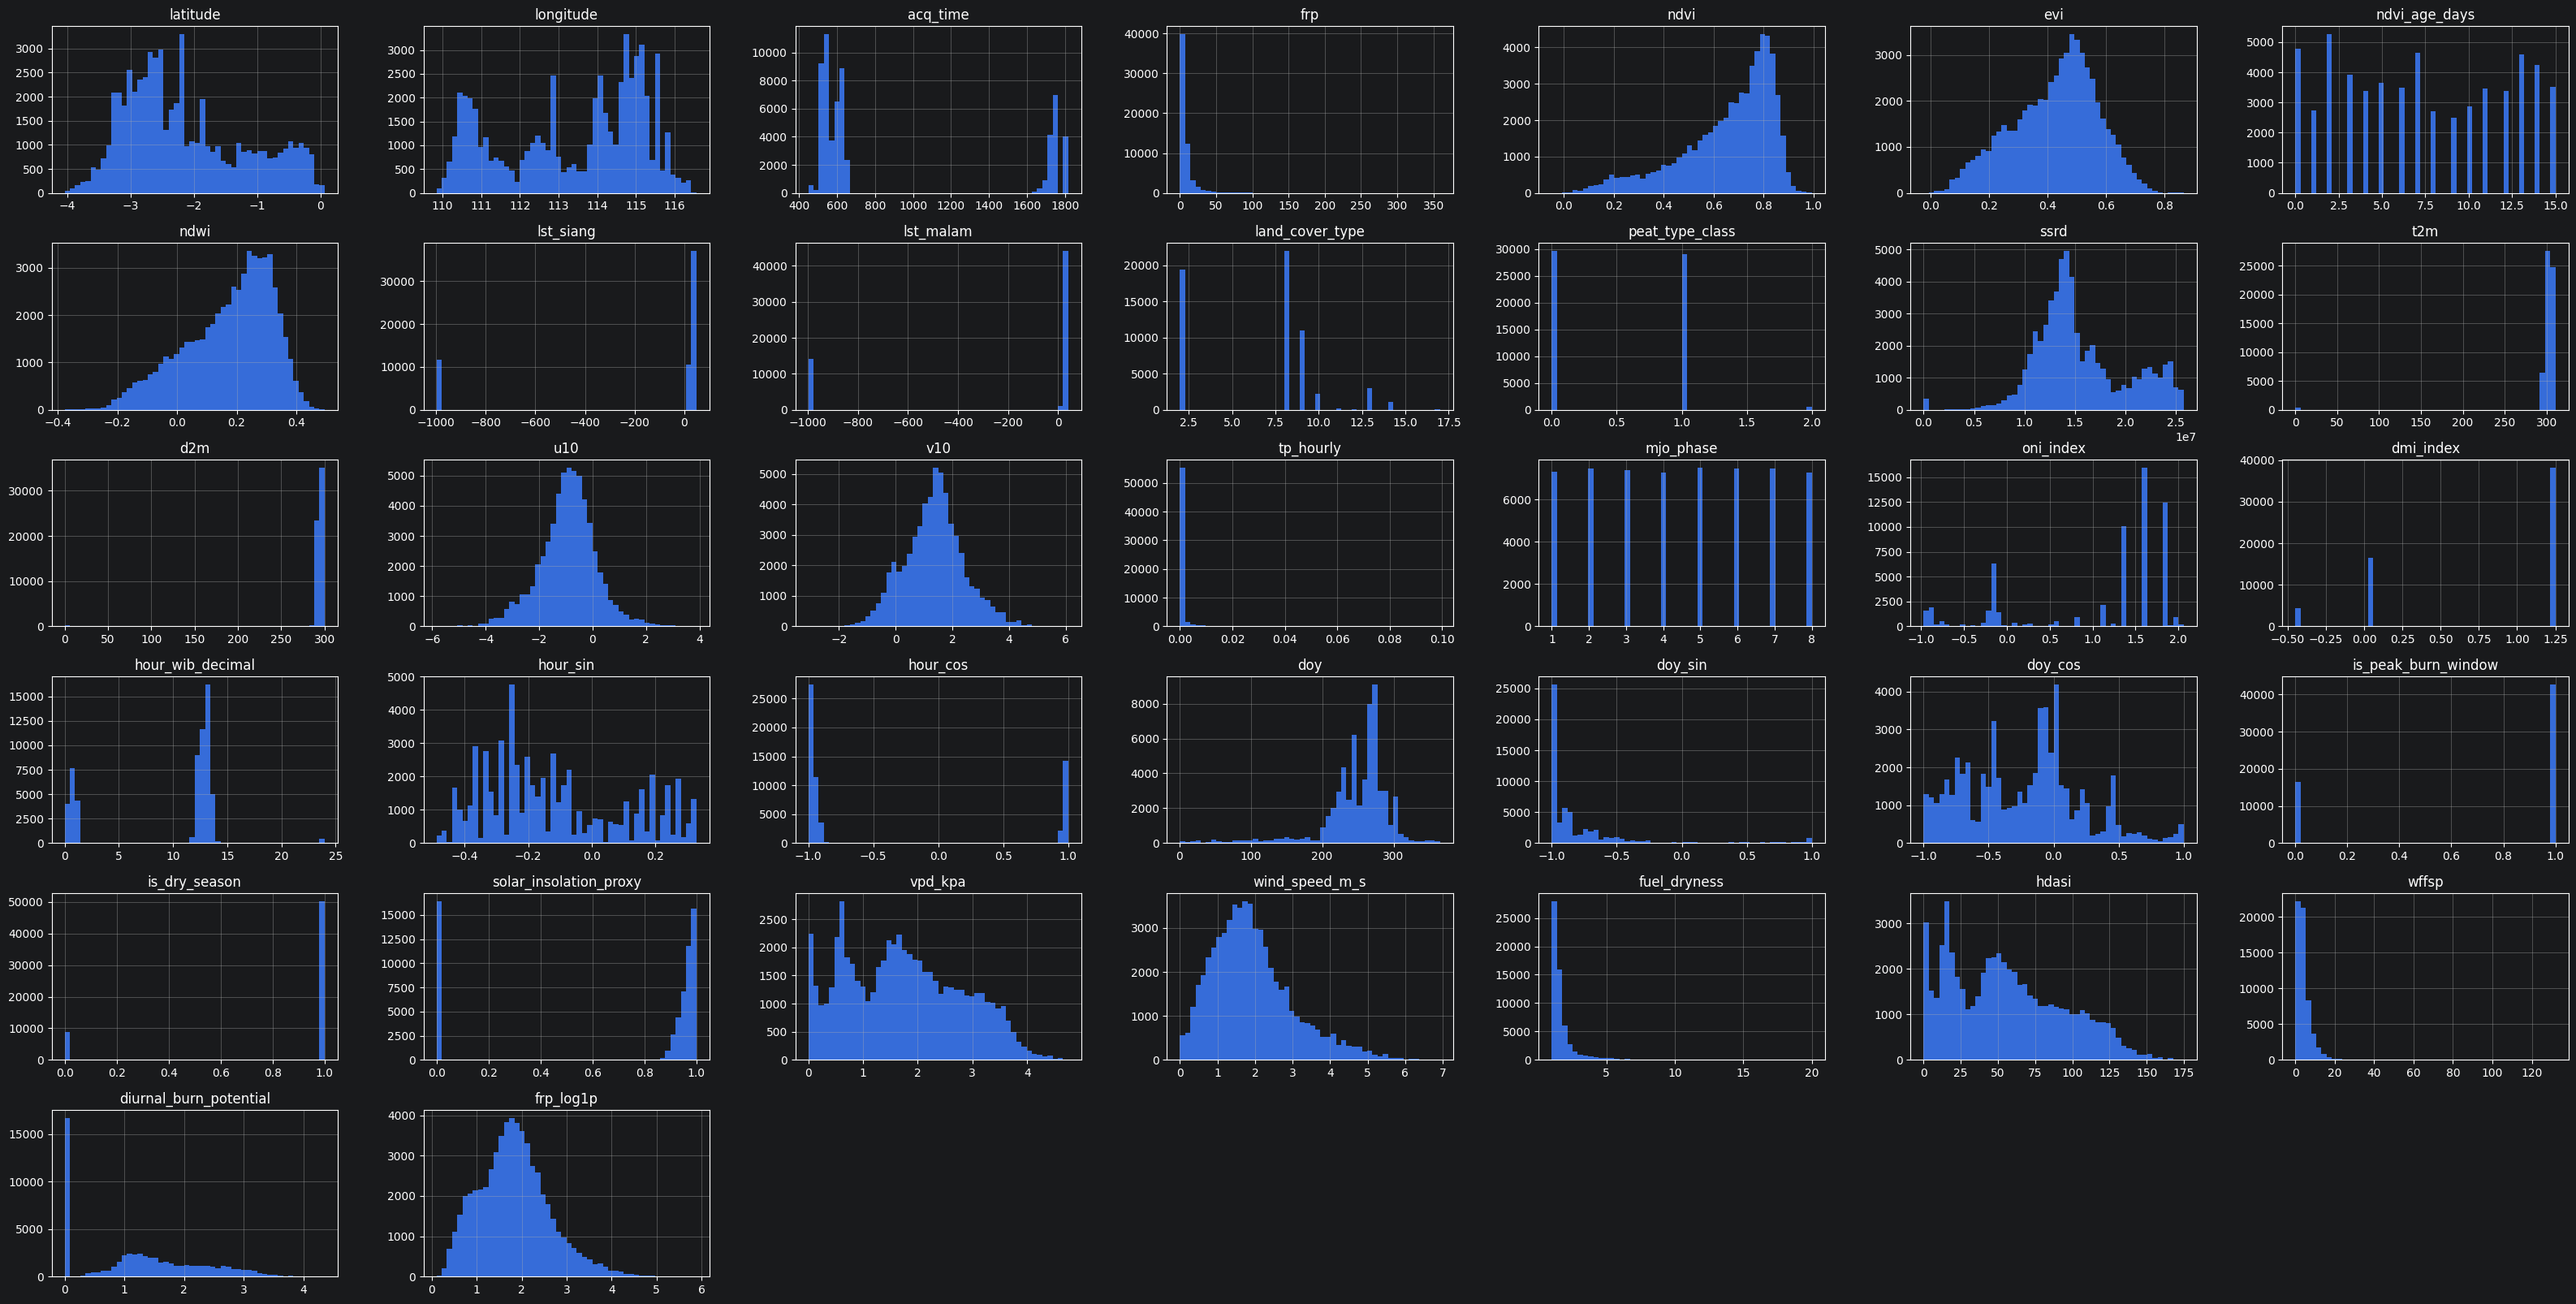

In [ ]:
df.hist(bins=50, figsize=(40, 20), layout=(6,7))

## Train-Test Split

The dataset has temporal attributes. It will be split into train and test set using the TimeSeries Cross-Validation approach to avoid data leakage, where we do training with future data and evaluating with past data since it doesn't make sense. Cross validation also helps capture

To ensure all splits are representative, each split contains training data starting from the first season and will be expanded by the next season in the next split. The testing data is from the season right after the last date of the training set.


In [ ]:
drop_cols = [
    # Target and its raw version
    'frp', 'frp_log1p',

    # Non-numeric / identifier columns
    'acq_date', 'satellite', 'enso_phase',

    # Replaced by cyclical encodings
    'hour_wib_decimal', 'doy', 'acq_time',
]

# Cast to datetime and sort
df['acq_date'] = pd.to_datetime(df['acq_date'])
df = df.sort_values('acq_date').reset_index(drop=True)

# Re-apply X and y after sorting
X = df.drop(columns=drop_cols)
y = df['frp_log1p']

print(X.columns.tolist())
print(X.shape)

['latitude', 'longitude', 'ndvi', 'evi', 'ndvi_age_days', 'ndwi', 'lst_siang', 'lst_malam', 'land_cover_type', 'peat_type_class', 'ssrd', 't2m', 'd2m', 'u10', 'v10', 'tp_hourly', 'mjo_phase', 'oni_index', 'dmi_index', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'is_peak_burn_window', 'is_dry_season', 'solar_insolation_proxy', 'vpd_kpa', 'wind_speed_m_s', 'fuel_dryness', 'hdasi', 'wffsp', 'diurnal_burn_potential']
(59155, 32)


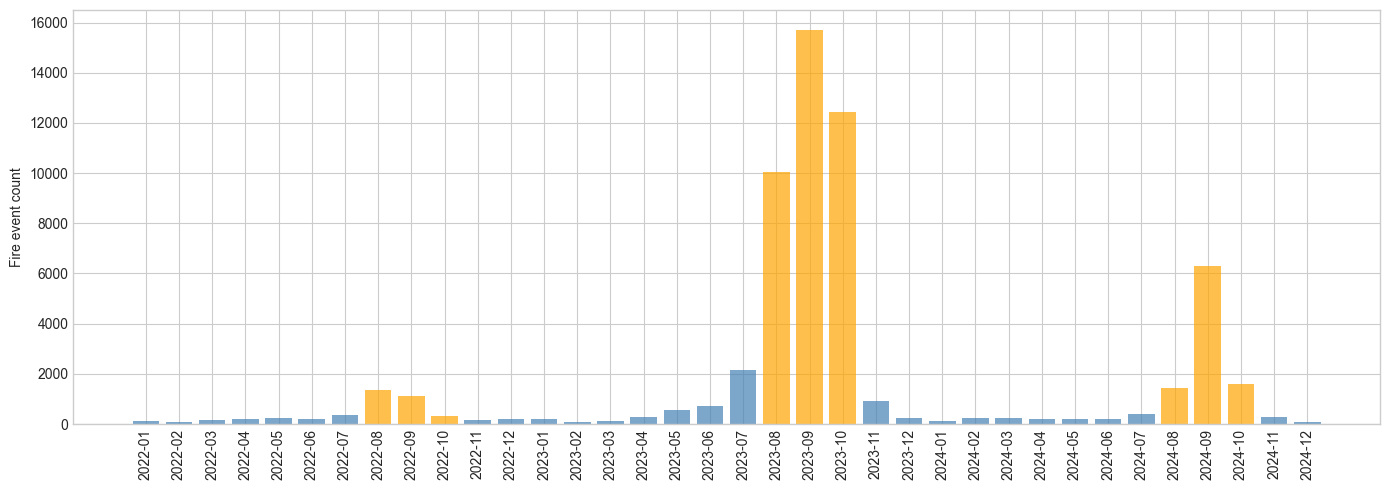

In [ ]:
monthly = df.groupby(df['acq_date'].dt.to_period('M')).agg(
    count=('frp', 'count'),
    dry_season=('is_dry_season', 'max')  # 1 if any dry season in that month
).reset_index()

colors = ['orange' if d == 1 else 'steelblue' for d in monthly['dry_season']]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly['acq_date'].astype(str), monthly['count'], color=colors, alpha=0.7)
ax.set_ylabel('Fire event count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
splits = [
    ('2022-01-01', '2022-07-31', '2022-08-01', '2022-10-31'),  # test: dry 2022
    ('2022-01-01', '2022-10-31', '2022-11-01', '2023-07-31'),  # test: wet 2022-23
    ('2022-01-01', '2023-07-31', '2023-08-01', '2023-10-31'),  # test: dry 2023
    ('2022-01-01', '2023-10-31', '2023-11-01', '2024-07-31'),  # test: wet 2023-24
    ('2022-01-01', '2024-07-31', '2024-08-01', '2024-12-29'),  # test: dry 2024
]

### Manual split by season

- Time period is more meaningful
- Covers dry/wet season alternately
- Unbalanced data rows

In [ ]:
for i, (train_start, train_end, test_start, test_end) in enumerate(splits):
    train_idx = (df['acq_date'] >= train_start) & (df['acq_date'] <= train_end)
    test_idx  = (df['acq_date'] >= test_start) & (df['acq_date'] <= test_end)
    print(f"Fold {i+1}: Train={train_idx.sum()} | Test={test_idx.sum()} | Test: {test_start} to {test_end}")

Fold 1: Train=1372 | Test=2777 | Test: 2022-08-01 to 2022-10-31
Fold 2: Train=4149 | Test=4400 | Test: 2022-11-01 to 2023-07-31
Fold 3: Train=8549 | Test=38185 | Test: 2023-08-01 to 2023-10-31
Fold 4: Train=46734 | Test=2745 | Test: 2023-11-01 to 2024-07-31
Fold 5: Train=49479 | Test=9676 | Test: 2024-08-01 to 2024-12-29


### Sklearn TimeSeriesSplit by rows

- Data row counts are even
- Unbalanced time period

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    train_dates = df['acq_date'].iloc[train_idx]
    test_dates = df['acq_date'].iloc[test_idx]
    print(f"Fold {i+1}: Train={len(train_idx)} | Test={len(test_idx)} | Test: {test_dates.min().date()} to {test_dates.max().date()}")

Fold 1: Train=9860 | Test=9859 | Test: 2023-08-07 to 2023-09-02
Fold 2: Train=19719 | Test=9859 | Test: 2023-09-02 to 2023-09-27
Fold 3: Train=29578 | Test=9859 | Test: 2023-09-27 to 2023-10-05
Fold 4: Train=39437 | Test=9859 | Test: 2023-10-05 to 2024-07-21
Fold 5: Train=49296 | Test=9859 | Test: 2024-07-21 to 2024-12-29


In [ ]:
split_idx = int(len(df) * 0.8)
X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print(f"Train: {X_train.shape} | {df['acq_date'].iloc[:split_idx].min().date()} to {df['acq_date'].iloc[:split_idx].max().date()}")
print(f"Test:  {X_test.shape}  | {df['acq_date'].iloc[split_idx:].min().date()} to {df['acq_date'].iloc[split_idx:].max().date()}")

Train: (47324, 32) | 2022-01-01 to 2023-11-11
Test:  (11831, 32)  | 2023-11-11 to 2024-12-29


In [ ]:
print("X_train NaN:", X_train.isnull().sum().sum())
print("X_test NaN:", X_test.isnull().sum().sum())
print("y_train NaN:", y_train.isnull().sum())
print("y_test NaN:", y_test.isnull().sum())

X_train NaN: 0
X_test NaN: 0
y_train NaN: 0
y_test NaN: 0


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

model = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse:.4f}")

RMSE: 0.6522


In [ ]:
import numpy as np

# Baseline: what if we just predicted the mean every time?
y_mean_pred = np.full_like(y_test, y_train.mean())
rmse_baseline = root_mean_squared_error(y_test, y_mean_pred)
print(f"Naive baseline RMSE: {rmse_baseline:.4f}")
print(f"Random Forest RMSE:  {rmse:.4f}")

Naive baseline RMSE: 0.8215
Random Forest RMSE:  0.6522


In [ ]:
# Convert back to original FRP scale to interpret error
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)
rmse_original = root_mean_squared_error(y_test_original, y_pred_original)
print(f"RMSE in original FRP units: {rmse_original:.2f} MW")
print(f"Mean FRP in test set: {y_test_original.mean():.2f} MW")
print(f"Median FRP in test set: {y_test_original.median():.2f} MW")

RMSE in original FRP units: 12.77 MW
Mean FRP in test set: 8.90 MW
Median FRP in test set: 5.24 MW


In [ ]:
# Look at where the large errors are
errors = np.abs(y_test_original - y_pred_original)
print(f"90th percentile error: {np.percentile(errors, 90):.2f} MW")
print(f"95th percentile error: {np.percentile(errors, 95):.2f} MW")
print(f"99th percentile error: {np.percentile(errors, 99):.2f} MW")
print(f"Max error: {errors.max():.2f} MW")

90th percentile error: 11.39 MW
95th percentile error: 22.26 MW
99th percentile error: 56.79 MW
Max error: 350.34 MW


In [ ]:
df['acq_date'] = pd.to_datetime(df['acq_date'])

for i, (train_start, train_end, test_start, test_end) in enumerate(splits):
    train = df[(df['acq_date'] >= train_start) & (df['acq_date'] <= train_end)]
    test  = df[(df['acq_date'] >= test_start) & (df['acq_date'] <= test_end)]
    print(f"Fold {i+1}: Train={len(train)} rows | Test={len(test)} rows | Test: {test_start} to {test_end}")

Fold 1: Train=1372 rows | Test=2777 rows | Test: 2022-08-01 to 2022-10-31
Fold 2: Train=4149 rows | Test=4400 rows | Test: 2022-11-01 to 2023-07-31
Fold 3: Train=8549 rows | Test=38185 rows | Test: 2023-08-01 to 2023-10-31
Fold 4: Train=46734 rows | Test=2745 rows | Test: 2023-11-01 to 2024-07-31
Fold 5: Train=49479 rows | Test=9676 rows | Test: 2024-08-01 to 2024-12-29


In [ ]:
# Find coordinates that appear multiple times
coord_counts = df.groupby(['latitude', 'longitude']).size().sort_values(ascending=False)
print(coord_counts.head(10))

latitude   longitude 
-2.211331  115.494904    2
-2.211032  115.495818    2
-2.212490  115.496202    2
-2.999561  115.202477    2
-1.893789  115.864145    1
-1.893780  115.866624    1
-1.893771  115.862718    1
           115.865045    1
-1.893740  115.864542    1
           115.863569    1
dtype: int64


In [ ]:
# Take the most frequent coordinate
top_lat, top_lon = coord_counts.index[0]

# Filter and sort by date
df_coord = df[(df['latitude'] == top_lat) & (df['longitude'] == top_lon)]\
             .sort_values('acq_date')[['acq_date', 'acq_time', 'frp', 'frp_log1p']]

print(df_coord)

        acq_date  acq_time   frp  frp_log1p
48272 2024-03-11    1744.0  2.59   1.278152
48663 2024-04-28    1744.0  1.26   0.815365


In [ ]:
tscv = TimeSeriesSplit()

for fold, (train_index, test_index) in enumerate(tscv.split(df_sorted_date)):
    print(f"Fold {fold+1}: Train {df_sorted_date['acq_date'].iloc[train_index].min()} to {df_sorted_date['acq_date'].iloc[train_index].max()}; Test {df_sorted_date['acq_date'].iloc[test_index].min()} to {df_sorted_date['acq_date'].iloc[test_index].max()}")

NameError: name 'df_sorted_date' is not defined

In [ ]:
print(df_sorted_date.groupby('is_dry_season')['acq_date'].agg(['min', 'max', 'count']))

In [ ]:
# See how fire events distribute across months
df_sorted_date['month'] = pd.to_datetime(df_sorted_date['acq_date']).dt.month
print(df_sorted_date.groupby('month')['frp'].agg(['count', 'mean']).round(2))

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Define features and target
drop_cols = ['acq_date', 'satellite', 'enso_phase', 'frp', 'frp_log1p']
X = df.drop(columns=drop_cols)
y = df['frp_log1p']

# Single time-based split for now
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Train
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
# Create a mask where neither y_test nor y_pred is NaN
mask = ~np.isnan(y_test) & ~np.isnan(y_pred)

# Calculate RMSLE only on the valid entries
rmsle = np.sqrt(mean_squared_error(y_test[mask], y_pred[mask]))
print(f"RMSLE (valid entries only): {rmsle:.4f}")